# 전처리 — 염소 분만 조기탐지

원본 20Hz 센서 CSV를 로드하여 **GAM-EWMA 모델(`GAM-EWMA.ipynb`)에 바로 사용할 수 있는 최종 데이터셋**을 만든다.

1. 원시 데이터
2. 데이터 정제 (A: 센서 중단 확인 및 보간, B: 이상치 처리, C: class 검증 및 분석구간 설정)
3. ODBA 산출 (2.5초 간격)
4. 1분 단위 통합
5. 시간창 파생변수
6. 라벨 생성 및 저장

In [2]:
# =========================================================
# 경로 설정
# =========================================================
import os, glob, re, time, tarfile, warnings, datetime as dt, traceback

import numpy as np
import pandas as pd
import polars as pl

warnings.filterwarnings("ignore")

TAR_PATH = r"C:\Users\chs02\OneDrive\바탕 화면\dataset\dataset_tar.xz"
DATA_DIR = r"C:\Users\chs02\OneDrive\바탕 화면\dataset\dataset"
SAVE_DIR = r"C:\Users\chs02\OneDrive\바탕 화면\dataset\dataset\processed"
PREPROCESS_SAVE_DIR = os.path.join(SAVE_DIR, "전처리")   # 개체별/통합 CSV 저장 위치
os.makedirs(PREPROCESS_SAVE_DIR, exist_ok=True)

if not glob.glob(os.path.join(DATA_DIR, "goat_*_annotated.csv")):
    with tarfile.open(TAR_PATH, mode="r:xz") as tf:
        tf.extractall(os.path.dirname(DATA_DIR))

In [3]:
# =========================================================
# Config
# =========================================================
SEED = 42
np.random.seed(SEED)

CFG = dict(
    # ---- 원자료 단위/컬럼 ----
    gram_unit_goat_ids=set(range(1, 11)),          # goat_01~10만 g 단위로 수집 -> mg로 통일
    acc_cols=["Acc_X (mg)", "Acc_Y (mg)", "Acc_Z (mg)"],
    temp_col="Temperature (ºC)",
    raw_col_alias={"Acc_X (mg)": "X", "Acc_Y (mg)": "Y", "Acc_Z (mg)": "Z", "Temperature (ºC)": "Temp"},

    # ---- 세그먼트 분리 / 리샘플 품질 ----
    gap_threshold_ms=3_600_000,          # 시계열 단절 기준
    max_isolation_gap_hours=24 * 7,      # 고립 세그먼트 제외 기준

    # ---- 원시 센서 QC(가속도 행 제거 / 온도 값만 null) ----
    acc_valid_range={"Acc_X (mg)": (-20000.0, 20000.0),
                      "Acc_Y (mg)": (-20000.0, 20000.0),
                      "Acc_Z (mg)": (-20000.0, 20000.0)},
    temp_valid_range=(-10.0, 50.0),
    spike_mad_mult=15.0,          # 스파이크 후보 기준
    spike_return_mad_mult=3.0,    # 정상 복귀 기준
    spike_isolated_max_run=2,     # 고립 스파이크 최대 길이

    # ---- Class_correct / 카운트다운 보정 ----
    leading_check_window_min=180,        # 카운트다운 시작 전 확인 구간
    min_sustained_baseline_min=30,       # 정상구간 최소 유지시간
    max_countdown_hours=13,              # 유효한 분만 최대 시간 길이
    countdown_min=60,                    # Class 1~13 구간 길이(분)

    # ---- ODBA (20Hz -> 10초 window, 2.5초 stride) ----
    fs_hz=20,                   # 가속도 센서 샘플링 주파수
    median_window_sec=10,       # window 폭
    median_overlap=0.75,        # window 중첩 비율 (2.5초 간격)

    # ---- baseline / 라벨 ----
    calib_pct=0.90,              # high-activity 판정 기준
    h_target=2,                  # 분만 전 2시간 이내

    # ---- 최종 입력변수: causal rolling window(분) ----
    win_o30=30, win_d15=15, win_mad15=15, win_act15=15, win_temp60=60,
)
CFG["countdown_n_classes"] = CFG["max_countdown_hours"]

# 알려진 특이 개체 (censored)
KNOWN_ISSUES = {
    20: {"issue": "censored_early_end", "note": "분만 전 관측 조기 종료(우측 절단), 약 7.5h"},
}

# 개체별 수동 분만 anchor/시각 override — raw에 -1 라벨이 없는 특이 사례를 연구자가 직접 지정
MANUAL_BIRTH_OVERRIDE = {
    8: {
        "anchor": 1711904100000, "birth": 1711904700000,
        "basis": "individual_template", "confidence": "high",
        "note": "2번째(관측된) 카운트다운과 동일 템플릿(Class1 55분+Class0 10분) 외삽.",
    },
    1: {
        "anchor": 1711817700000, "birth": 1711818300000,
        "basis": "population_template", "confidence": "low",
        "note": "Class=1 설계 길이(55분)를 채운 시점에서 우측절단. 모집단 평균 Class0(10분)로 외삽(저신뢰).",
    },
}

In [4]:
# =========================================================
# 데이터 로드
# =========================================================
files_list = sorted(glob.glob(os.path.join(DATA_DIR, "goat_*_annotated.csv")))


def get_goat_id(fname):
    """파일명(goat_XX_annotated.csv)에서 개체 ID를 추출한다."""
    return int(re.match(r"goat_(\d+)_", os.path.basename(fname)).group(1))


def detect_acc_unit(gid):
    """개체별 가속도 원 단위(g/mg)를 판별한다."""
    return "g" if gid in CFG["gram_unit_goat_ids"] else "mg"


def read_raw_csv(fpath, gid, columns=None):
    """원시 CSV를 로드하고, g단위로 수집된 개체는 x1000 하여 mg로 통일한다."""
    df = pl.read_csv(fpath, columns=columns) if columns else pl.read_csv(fpath)
    if detect_acc_unit(gid) == "g":
        cols = [c for c in CFG["acc_cols"] if c in df.columns]
        if cols:
            df = df.with_columns([(pl.col(c) * 1000).alias(c) for c in cols])
    return df


goat_ids_available = sorted(get_goat_id(f) for f in files_list)

In [5]:
# =========================================================
# 함수 정의
# =========================================================
# --- [2-A] 센서 중단 확인(세그먼트 분리) / 1분 리샘플 --------------------------
def get_main_segments(df_time_class):
    """1시간+ gap으로 세그먼트를 분리한 뒤, 본 세그먼트와 7일+ 떨어진 고립 구간을 제외한다."""
    df_sorted = df_time_class.sort("Time")
    diffs = df_sorted.with_columns(d=pl.col("Time").diff())
    gap_idx = diffs.with_row_index().filter(pl.col("d") >= CFG["gap_threshold_ms"])["index"].to_list()
    times = df_sorted["Time"].to_list()
    t_min, t_max = times[0], times[-1]
    seg_starts, seg_ends = [t_min], []
    for idx in gap_idx:
        seg_ends.append(times[idx - 1]); seg_starts.append(times[idx])
    seg_ends.append(t_max)
    segs = sorted(zip(seg_starts, seg_ends), key=lambda se: se[1] - se[0], reverse=True)
    main_start, main_end = segs[0]
    keep = []
    for s, e in segs:
        dist_hr = min(abs(s - main_end), abs(main_start - e)) / (1000 * 3600)
        if (s, e) == (main_start, main_end) or dist_hr <= CFG["max_isolation_gap_hours"]:
            keep.append((s, e))
    return keep, len(gap_idx), round(sum(e - s for s, e in keep) / (1000 * 3600), 2)


def filter_to_main_segments(df, segments):
    """본 세그먼트(고립 구간 제외)만 남기고 필터링한다."""
    cond = None
    for s, e in segments:
        c = (pl.col("Time") >= s) & (pl.col("Time") <= e)
        cond = c if cond is None else (cond | c)
    return df.filter(cond)


def resample_1min(df, gid):
    """20Hz 원자료를 1분 단위로 집계한다(가속도/온도 평균)"""
    col_x, col_y, col_z, col_t = *CFG["acc_cols"], CFG["temp_col"]
    df = df.with_columns((pl.col("Time") // 60_000 * 60_000).alias("minute_bucket"))
    agg = [
        pl.col(col_x).mean().alias(col_x), pl.col(col_y).mean().alias(col_y), pl.col(col_z).mean().alias(col_z),
        pl.col(col_t).mean().alias(col_t), pl.col(col_t).count().alias("n_temp_valid"),
        pl.col("Class").mode().first().alias("Class"), pl.col("Time").count().alias("n_samples_in_bucket"),
    ]
    out = df.group_by("minute_bucket").agg(agg).sort("minute_bucket")
    return out.rename({"minute_bucket": "Time"}).with_columns(pl.lit(gid).alias("goat_id"))

In [6]:
# --- [2-B] 이상치 처리: 가속도 행 제거 / 온도 값만 null -----------------------
def flag_raw_outliers(df):
    """가속도 물리범위 위반 + 고립 스파이크는 행 제거 후보로, 온도 범위 위반은 값만 null로 표시한다."""
    acc_valid_range, temp_col, temp_valid_range = CFG["acc_valid_range"], CFG["temp_col"], CFG["temp_valid_range"]
    spike_mad_mult, return_mad_mult, isolated_max_run = (
        CFG["spike_mad_mult"], CFG["spike_return_mad_mult"], CFG["spike_isolated_max_run"]
    )

    d = df.sort("Time")
    n = d.height
    accel_outlier = np.zeros(n, dtype=bool)
    detail = {}

    # 1) 가속도 물리 범위 위반: X/Y/Z 중 하나라도 위반하면 해당 20Hz 행 제거
    for c, (lo, hi) in acc_valid_range.items():
        vals = d[c].to_numpy()
        rng_flag = (vals < lo) | (vals > hi)
        tag = CFG["raw_col_alias"][c]
        detail[tag] = {"range": int(rng_flag.sum())}
        accel_outlier |= rng_flag

    # 2) 가속도 고립 스파이크: 짧고 시작 전 수준으로 복귀하는 경우만 제거
    for c in acc_valid_range:
        vals = d[c].to_numpy().astype(np.float64)
        diff_abs = np.abs(np.diff(vals, prepend=vals[0]))
        diff_abs[0] = 0.0
        med_diff = np.median(diff_abs)
        mad_diff = np.median(np.abs(diff_abs - med_diff))
        scale = 1.4826 * mad_diff if mad_diff > 0 else max(med_diff, 1e-6)

        cand = diff_abs > (spike_mad_mult * scale)
        tag = CFG["raw_col_alias"][c]
        n_isolated = 0
        if cand.any():
            edges = np.flatnonzero(np.diff(np.concatenate(([0], cand.astype(int), [0]))))
            starts, ends = edges[0::2], edges[1::2] - 1
            for s, e in zip(starts, ends):
                if (e - s + 1) > isolated_max_run:
                    continue
                pre_idx, post_idx = s - 1, e + 1
                if pre_idx < 0 or post_idx >= n:
                    continue
                if abs(vals[post_idx] - vals[pre_idx]) <= (return_mad_mult * scale):
                    accel_outlier[s:e + 1] = True
                    n_isolated += e - s + 1
        detail[tag]["spike_candidates"] = int(cand.sum())
        detail[tag]["spike_removed_isolated"] = int(n_isolated)

    # 3) 온도 범위 위반: 행 삭제 금지, Temperature 값만 null 처리
    temp_lo, temp_hi = temp_valid_range
    temp_invalid_expr = (
        pl.col(temp_col).is_null() | (pl.col(temp_col) < temp_lo) | (pl.col(temp_col) > temp_hi)
    )
    detail[CFG["raw_col_alias"][temp_col]] = {"range_to_null": int(d.select(temp_invalid_expr.sum()).item())}

    d = d.with_columns([
        pl.when(temp_invalid_expr).then(None).otherwise(pl.col(temp_col)).cast(pl.Float64).alias(temp_col),
        pl.Series("_is_accel_outlier", accel_outlier),
    ])
    return d, detail


def drop_raw_outliers(df):
    """확정된 가속도 이상 행만 삭제한다"""
    flagged, detail = flag_raw_outliers(df)
    removed_accel = (flagged.filter(pl.col("_is_accel_outlier"))
                             .select(["Time"] + CFG["acc_cols"])
                             .with_columns([pl.col(c).cast(pl.Float64) for c in CFG["acc_cols"]]))
    cleaned = flagged.filter(~pl.col("_is_accel_outlier")).drop("_is_accel_outlier")
    return cleaned, removed_accel, detail

In [7]:
# --- [2-C] class 검증 및 분석구간 설정(카운트다운 보정) ------------------------
def _find_sustained_baseline_start(classes, start, end, min_sustained_min):
    """[start, end) 구간에서 Class==13이 min_sustained_min분 이상 연속되는 시작 인덱스를 찾는다."""
    n, i = len(classes), start
    while i < end:
        if classes[i] == 13:
            j = i
            while j < n and classes[j] == 13:
                j += 1
            if j - i >= min_sustained_min:
                return i
            i = j
        else:
            i += 1
    return None


def detect_leading_nonbaseline_block(df):
    """관측 시작부의 Class!=13 블록을 판별한다."""
    df_sorted = df.sort("Time")
    classes, times = df_sorted["Class"].to_list(), df_sorted["Time"].to_list()
    n = len(classes)
    window_end = min(CFG["leading_check_window_min"], n)
    idx = _find_sustained_baseline_start(classes, 0, window_end, CFG["min_sustained_baseline_min"])
    if idx is not None:
        return None if idx == 0 else {"cutoff_time": times[idx], "unresolved": False}
    if -1 in set(classes[:window_end]):
        idx = _find_sustained_baseline_start(classes, 0, n, CFG["min_sustained_baseline_min"])
        if idx is not None:
            return None if idx == 0 else {"cutoff_time": times[idx], "unresolved": False}
        return {"unresolved": True}
    return {"unresolved": True}


def get_fake13_blocks_raw_safe(fpath, max_block_duration_min=15):
    """1 -> 13(짧게) -> 0 패턴의 가짜 Class=13 아티팩트 블록만 인정하여 반환한다."""
    df = pl.read_csv(fpath, columns=["Time", "Class"]).sort("Time")
    df = df.with_columns(prev_class=pl.col("Class").shift(1), next_class=pl.col("Class").shift(-1))
    starts = df.filter((pl.col("Class") == 13) & (pl.col("prev_class") == 1))["Time"].to_list()
    ends = df.filter((pl.col("Class") == 13) & (pl.col("next_class") == 0))["Time"].to_list()
    blocks = []
    for s in starts:
        cand = [e for e in ends if e >= s]
        if not cand:
            continue
        e = min(cand)
        if (e - s) / 60000 <= max_block_duration_min:
            blocks.append((s, e))
    return blocks


def get_birth_events(df, class_col="Class_correct"):
    """class_col이 -1로 처음 진입하는 시각들(분만 시각)을 반환한다."""
    d = df.sort("Time").with_columns(prev_class=pl.col(class_col).shift(1))
    return d.filter((pl.col(class_col) == -1) & (pl.col("prev_class") != -1) &
                     (pl.col("prev_class").is_not_null()))["Time"].to_list()


def find_pre_birth_zero_anchor(df, t_birth, class_col="Class_correct"):
    """Class=0 블록의 시작 시각(anchor)을 찾는다. """
    d = df.filter(pl.col("Time") < t_birth).sort("Time", descending=True)
    times, classes = d["Time"].to_list(), d[class_col].to_list()
    anchor, expected = t_birth, t_birth - 60_000
    for t, c in zip(times, classes):
        if t == expected and c == 0:
            anchor = t
            expected -= 60_000
        else:
            break
    return anchor


def build_countdown_boundaries(anchor):
    """카운트다운 Class 구간 경계."""
    countdown_min, n_classes = CFG["countdown_min"], CFG["countdown_n_classes"]
    boundaries = []
    end = anchor
    for k in range(1, n_classes + 1):
        start = end - countdown_min * 60_000
        boundaries.append((k, start, end))
        end = start
    return boundaries


def fill_missing_minutes_in_window(df, gid, anchor):
    """수치형 컬럼은 윈도우 안팎 실측 앵커를 포함해 선형보간하고, 그래도 안 채워지면 구간 평균으로 채운다."""
    countdown_min, n_classes = CFG["countdown_min"], CFG["countdown_n_classes"]
    window_start = anchor - countdown_min * n_classes * 60_000
    window_end = anchor

    full_grid = pl.DataFrame({"Time": list(range(window_start, window_end, 60_000))}).cast({"Time": pl.Int64})
    in_window = (pl.col("Time") >= window_start) & (pl.col("Time") < window_end)
    existing = df.filter(in_window)
    outside = df.filter(~in_window)

    n_expected = (window_end - window_start) // 60_000
    if existing.height > n_expected:
        existing = existing.unique(subset=["Time"], keep="first")

    before_anchor = df.filter(pl.col("Time") < window_start).sort("Time").tail(1)
    after_anchor = df.filter(pl.col("Time") >= window_end).sort("Time").head(1)
    anchor_rows = pl.concat([before_anchor, after_anchor], how="vertical") if (before_anchor.height or after_anchor.height) else None

    merged = full_grid.join(existing, on="Time", how="left").sort("Time")
    skip_cols = {"Time", "goat_id", "Class", "Class_correct"}
    numeric_cols = [c for c, dtp in df.schema.items() if c not in skip_cols and dtp.is_numeric()]

    if anchor_rows is not None and anchor_rows.height > 0:
        extended = (pl.concat([anchor_rows.select(merged.columns), merged], how="vertical")
                    .sort("Time").unique(subset=["Time"], keep="first").sort("Time"))
        extended = extended.with_columns([pl.col(c).interpolate() for c in numeric_cols])
        merged = extended.filter(in_window)
    else:
        merged = merged.with_columns([pl.col(c).interpolate() for c in numeric_cols])

    fallback_means = {c: (merged[c].mean() if merged[c].mean() is not None else 0.0) for c in numeric_cols}
    merged = merged.with_columns([pl.col(c).fill_null(fallback_means[c]) for c in numeric_cols])
    merged = merged.with_columns(pl.lit(gid).alias("goat_id"))
    if "Class_correct" in merged.columns:
        merged = merged.with_columns(pl.col("Class_correct").fill_null(13))
    merged = merged.select(df.columns).cast({c: df.schema[c] for c in df.columns})

    return pl.concat([outside, merged], how="vertical").sort("Time")


def fix_mislabeled_13_by_realtime_countdown(df, anchor, class_col="Class_correct"):
    if anchor is None:
        return df
    expr = pl.col(class_col)
    for class_val, start, end in build_countdown_boundaries(anchor):
        in_win = (pl.col("Time") >= start) & (pl.col("Time") < end)
        expr = pl.when(in_win).then(class_val).otherwise(expr)
    return df.with_columns(expr.alias(class_col))


def reset_stray_countdown_before_window(df, anchor, class_col="Class_correct"):
    n_classes = CFG["countdown_n_classes"]
    window_start = anchor - CFG["countdown_min"] * n_classes * 60_000
    stray = (pl.col("Time") < window_start) & (pl.col(class_col) >= 0) & (pl.col(class_col) <= n_classes)
    return df.with_columns(pl.when(stray).then(13).otherwise(pl.col(class_col)).alias(class_col))

In [8]:
# --- [2-C] 분만시점 / 분석구간 설정(1차 분만 주기 절단) -------------------------
def get_first_cycle_cutoff(df, birth_events, class_col="Class_correct"):
    """1차 분만 주기만 남기기 위한 절단 시각을 계산한다."""
    d = df.sort("Time")
    classes, times = d[class_col].to_list(), d["Time"].to_list()
    candidates = []  # (time, inclusive, anchor)

    if birth_events:
        t1 = min(birth_events)
        last_zero = d.filter((pl.col("Time") < t1) & (pl.col(class_col) == 0))["Time"].max()
        if last_zero is not None:
            candidates.append((last_zero, True, "zero"))
        else:
            block_starts = [times[i] for i in range(len(classes)) if classes[i] == 13 and (i == 0 or classes[i - 1] != 13)]
            if len(block_starts) >= 2:
                candidates.append((block_starts[1], False, "13block"))

    for i in range(1, len(classes)):
        if classes[i] == 13 and classes[i - 1] != 13 and (times[i] - times[i - 1]) < CFG["gap_threshold_ms"]:
            candidates.append((times[i], False, "increase"))
            break

    if not candidates:
        return None, None, None
    return min(candidates, key=lambda c: c[0])

In [9]:
# --- [3] ODBA 산출: 20Hz -> 10초 window(75% overlap, 2.5초 stride) -----------
def compute_odba_step(df):
    """window 자신의 raw 평균을 정적 성분으로 빼고(causal), |dX|+|dY|+|dZ|의 median을 대표값으로 삼는다."""
    col_x, col_y, col_z = CFG["acc_cols"]
    window_sec, overlap = CFG["median_window_sec"], CFG["median_overlap"]

    df = df.select(["Time", col_x, col_y, col_z]).sort("Time")
    empty = pl.DataFrame({"Time": [], "ODBA_step": [], "minute_bucket": []},
                          schema={"Time": pl.Int64, "ODBA_step": pl.Float64, "minute_bucket": pl.Int64})
    if df.height == 0:
        return empty

    times = df["Time"].to_numpy()
    ax, ay, az = df[col_x].to_numpy(), df[col_y].to_numpy(), df[col_z].to_numpy()

    window_ms = int(window_sec * 1000)
    step_ms = int(window_sec * (1 - overlap) * 1000)
    t0, t_end = int(times[0]), int(times[-1])
    first_t = t0 + window_ms
    if first_t > t_end:
        return empty

    n_steps = (t_end - first_t) // step_ms + 1
    t_grid = first_t + step_ms * np.arange(n_steps)
    lo_idx = np.searchsorted(times, t_grid - window_ms, side="right")
    hi_idx = np.searchsorted(times, t_grid, side="right")

    vals = np.full(len(t_grid), np.nan)
    for i in range(len(t_grid)):
        lo, hi = lo_idx[i], hi_idx[i]
        if hi <= lo:
            continue
        seg_x, seg_y, seg_z = ax[lo:hi], ay[lo:hi], az[lo:hi]
        static_x, static_y, static_z = seg_x.mean(), seg_y.mean(), seg_z.mean()
        odba_inst = np.abs(seg_x - static_x) + np.abs(seg_y - static_y) + np.abs(seg_z - static_z)
        vals[i] = np.median(odba_inst)

    return (pl.DataFrame({"Time": t_grid.astype(np.int64), "ODBA_step": vals})
            .filter(pl.col("ODBA_step").is_finite())
            .with_columns((pl.col("Time") // 60_000 * 60_000).alias("minute_bucket")))


# --- [4] 1분 단위 통합: ODBA 평균/MAD, 고활동 비율 -----------------------------
def _mad(y):
    """1분 내 ODBA_step에 적용하는 causal MAD(내부 헬퍼)."""
    m = np.median(y)
    return float(np.median(np.abs(y - m)))


def compute_odba_1min_local_features(step_df):
    """baseline 불필요, 그 1분 내부만으로 계산 가능한 특징(ODBA_level_1m: 평균, ODBA_MAD_1m: MAD)."""
    schema = {"Time": pl.Int64, "ODBA_level_1m": pl.Float64, "ODBA_MAD_1m": pl.Float64}
    if step_df.height == 0:
        return pl.DataFrame({k: [] for k in schema}, schema=schema)
    d = step_df.sort("Time").to_pandas()
    grp = d.groupby("minute_bucket")["ODBA_step"]
    out = grp.agg(ODBA_level_1m="mean").reset_index().rename(columns={"minute_bucket": "Time"})
    out["ODBA_MAD_1m"] = grp.apply(lambda s: _mad(s.to_numpy())).to_numpy()
    return pl.from_pandas(out[["Time", "ODBA_level_1m", "ODBA_MAD_1m"]])


def compute_odba_threshold_features(step_df, threshold):
    """baseline threshold(p90)가 필요한 특징: high_activity_proportion_1m(임계 초과 비율)."""
    schema = {"Time": pl.Int64, "high_activity_proportion_1m": pl.Float64}
    if step_df.height == 0:
        return pl.DataFrame({k: [] for k in schema}, schema=schema)
    d = step_df.sort("Time").to_pandas()
    d["is_high"] = (d["ODBA_step"] > threshold).astype(int)
    prop = d.groupby("minute_bucket")["is_high"].mean()
    out = pd.DataFrame({"Time": prop.index, "high_activity_proportion_1m": prop.to_numpy()})
    return pl.from_pandas(out)

In [10]:
# --- [5] 시간창 파생변수: causal rolling (O_30m / D_15-30m / MAD_15m / Act15m / Temp_60m) ----------
def add_causal_features(df):
    """모두 현재+과거 값만 사용하는 causal rolling(centered 금지).
    O_30m    : 최근 30분 활동수준(ODBA_level_1m 평균)
    D_15-30m : 15분 단기활동변화(최근 15분 평균 ODBA - 최근 30분 평균 ODBA)
    MAD_15m  : 최근 15분 활동변동성(ODBA_MAD_1m 평균)
    Act15m   : 최근 15분 고활동비율(high_activity_proportion_1m 평균)
    Temp_60m : 최근 60분 온도평균"""
    odba15 = pl.col("ODBA_level_1m").rolling_mean(window_size=CFG["win_d15"], min_periods=CFG["win_d15"])
    odba30 = pl.col("ODBA_level_1m").rolling_mean(window_size=CFG["win_o30"], min_periods=CFG["win_o30"])
    return df.sort("Time").with_columns([
        odba30.alias("O_30m"),
        (odba15 - odba30).alias("D_15-30m"),
        pl.col("ODBA_MAD_1m").rolling_mean(window_size=CFG["win_mad15"], min_periods=CFG["win_mad15"]).alias("MAD_15m"),
        pl.col("high_activity_proportion_1m").rolling_mean(window_size=CFG["win_act15"], min_periods=CFG["win_act15"]).alias("Act15m"),
        pl.col(CFG["temp_col"]).rolling_mean(window_size=CFG["win_temp60"], min_periods=CFG["win_temp60"]).alias("Temp_60m"),
    ])


FINAL_FEATURE_COLS = ["O_30m", "D_15-30m", "MAD_15m", "Act15m", "Temp_60m"]
TARGET_COL = "y_H2"   # 분만 전 h_target(=2)시간 이내 = 1, 그 외 정상 분석구간 = 0

In [11]:
# =========================================================
# 실행부 — 개체별 순차 처리 
# =========================================================
t_start = time.time()
normalized_final = {}
calib_odba_stats = []       # high_activity_proportion에 사용
structure_summary = []      # 개체별 데이터 품질 확인 요약(중복/gap/이상치/결측)
raw_outlier_records = []
failed_goats = []
qc_warnings = []            # 개체별 경고 -> 최종 저장 셀에서 한 번에 출력
error_log = []              # 개체별 예외 traceback -> 최종 저장 셀에서 한 번에 출력

for f in files_list:
    gid = get_goat_id(f)
    t0g = time.time()
    try:
        # ---- [2-A] 센서 중단 확인: 세그먼트 분리 ----
        tc = pl.read_csv(f, columns=["Time", "Class"])
        n_dup = tc.height - tc["Time"].n_unique()
        segs, n_gap, real_obs_hr = get_main_segments(tc)
        reached_parturition = (tc["Class"] == -1).sum() > 0

        df = read_raw_csv(f, gid).sort("Time")
        n_before = df.height
        df = filter_to_main_segments(df, segs)

        # ---- [2-B] 이상치 처리 ----
        df, removed, qc_detail = drop_raw_outliers(df)
        n_raw_outliers = removed.height
        n_temp_to_null = qc_detail.get("Temp", {}).get("range_to_null", 0)
        if n_raw_outliers:
            raw_outlier_records.append(removed.with_columns(pl.lit(gid).alias("goat_id")))
        n_after_qc = df.height

        # ---- [3] ODBA 산출(2.5초 step) → [4] 1분 단위 통합(level/MAD, baseline 불필요분) ----
        step_df = compute_odba_step(df)
        odba_local = compute_odba_1min_local_features(step_df)

        resampled = resample_1min(df, gid)   # [2-A]/[4] 1분 리샘플(가속도/온도/Class)
        expected_bucket_size = CFG["fs_hz"] * 60   # 20Hz x 60초 = 1분당 기대 샘플 수
        n_incomplete_pct = (resampled["n_samples_in_bucket"] < expected_bucket_size * 0.9).sum() / resampled.height * 100
        del df

        resampled = resampled.join(odba_local.select(["Time", "ODBA_level_1m", "ODBA_MAD_1m"]), on="Time", how="left")
        n_odba_na = resampled["ODBA_level_1m"].is_null().sum()
        if n_odba_na:
            resampled = resampled.with_columns([
                pl.col(c).fill_null(strategy="forward").fill_null(strategy="backward")
                for c in ["ODBA_level_1m", "ODBA_MAD_1m"]
            ])

        # ---- [2-C] class 검증 + 분만 이벤트 확인 ----
        info = detect_leading_nonbaseline_block(resampled)
        if info is not None and not info["unresolved"]:
            resampled = resampled.sort("Time").filter(pl.col("Time") >= info["cutoff_time"])

        blocks = get_fake13_blocks_raw_safe(f)
        class_correct = pl.col("Class")
        if blocks:
            mask = pl.lit(False)
            for s, e in blocks:
                s_bucket = (s // 60_000) * 60_000
                mask = mask | ((pl.col("Time") >= s_bucket) & (pl.col("Time") <= e) & (pl.col("Class") == 13))
            class_correct = pl.when(mask).then(0).otherwise(class_correct)
        resampled = resampled.with_columns(class_correct.alias("Class_correct"))

        # 1차 분만(첫 -1) 이후 데이터 하드 크롭. override 개체는 tail-fill 앵커 보존을 위해 뒤로 미룸.
        events_raw = get_birth_events(resampled)
        is_override = gid in MANUAL_BIRTH_OVERRIDE
        if is_override:
            t_birth = MANUAL_BIRTH_OVERRIDE[gid]["birth"]
            qc_warnings.append(f"goat_{gid:02d}: raw -1 라벨 없음 -> 수동 지정 분만시각 사용: {MANUAL_BIRTH_OVERRIDE[gid]['note']}")
        else:
            t_birth = min(events_raw) if events_raw else None
            if len(events_raw) > 1:
                qc_warnings.append(f"goat_{gid:02d}: 분만(-1) 이벤트 {len(events_raw)}개 -> 첫 번째만 사용, 이후 크롭")
            if t_birth is not None:
                resampled = resampled.filter(pl.col("Time") <= t_birth)

        # 실제시간 기준 카운트다운 Class 재계산
        if t_birth is not None:
            anchor = MANUAL_BIRTH_OVERRIDE[gid]["anchor"] if is_override else find_pre_birth_zero_anchor(resampled, t_birth)
            resampled = fill_missing_minutes_in_window(resampled, gid, anchor)
            resampled = fix_mislabeled_13_by_realtime_countdown(resampled, anchor)
            resampled = reset_stray_countdown_before_window(resampled, anchor)

            if is_override:
                # anchor~birth 구간(Class 0 + 분만 -1) 수동 생성
                anchor_, birth_ = MANUAL_BIRTH_OVERRIDE[gid]["anchor"], MANUAL_BIRTH_OVERRIDE[gid]["birth"]
                tail_grid = pl.DataFrame({"Time": list(range(anchor_, birth_ + 60_000, 60_000))}).cast({"Time": pl.Int64})
                in_tail = (pl.col("Time") >= anchor_) & (pl.col("Time") <= birth_)
                tail_existing, tail_outside = resampled.filter(in_tail), resampled.filter(~in_tail)

                before_anchor = resampled.filter(pl.col("Time") < anchor_).sort("Time").tail(1)
                after_anchor = resampled.filter(pl.col("Time") > birth_).sort("Time").head(1)
                anchor_rows = pl.concat([before_anchor, after_anchor], how="vertical")

                tail_merged = tail_grid.join(tail_existing, on="Time", how="left").sort("Time")
                skip_cols = {"Time", "goat_id", "Class", "Class_correct"}
                numeric_cols = [c for c, dtp in resampled.schema.items() if c not in skip_cols and dtp.is_numeric()]

                if after_anchor.height > 0:
                    extended = (pl.concat([anchor_rows.select(tail_merged.columns), tail_merged], how="vertical")
                                .sort("Time").unique(subset=["Time"], keep="first").sort("Time")
                                .with_columns([pl.col(c).interpolate() for c in numeric_cols]))
                    tail_merged = extended.filter(in_tail)
                else:
                    qc_warnings.append(f"goat_{gid:02d}: 뒤쪽 실측 앵커 없음(우측절단) -> forward-fill로 채움(confidence=low)")
                    fill_vals = before_anchor.select(numeric_cols) if before_anchor.height > 0 else None
                    if fill_vals is not None and fill_vals.height > 0:
                        tail_merged = tail_merged.with_columns([pl.lit(fill_vals[c][0]).alias(c) for c in numeric_cols])

                tail_merged = tail_merged.with_columns(pl.lit(gid).alias("goat_id"))
                tail_merged = tail_merged.with_columns(
                    pl.when(pl.col("Time") == birth_).then(-1).otherwise(0).alias("Class_correct")
                )
                tail_merged = tail_merged.with_columns(pl.col("Class_correct").alias("Class").cast(resampled.schema["Class"]))
                tail_merged = tail_merged.select(resampled.columns).cast({c: resampled.schema[c] for c in resampled.columns})
                resampled = pl.concat([tail_outside, tail_merged], how="vertical").sort("Time")
                resampled = resampled.filter(pl.col("Time") <= t_birth)

        events2 = sorted(get_birth_events(resampled))
        cutoff_time, cutoff_inclusive, cutoff_anchor = get_first_cycle_cutoff(resampled, events2)
        if cutoff_time is not None:
            cond = (pl.col("Time") <= cutoff_time) if cutoff_inclusive else (pl.col("Time") < cutoff_time)
            resampled = resampled.filter(cond)
        if cutoff_anchor is None:
            cutoff_anchor = "censored" if not events2 else "unresolved"

        # ---- [6] 라벨(y_H2) 생성: 분만 전 h_target 시간 이내=1, 그 외 정상 분석구간=0 ----
        resampled = resampled.with_columns(
            ((pl.col("Class_correct") >= 0) & (pl.col("Class_correct") <= CFG["h_target"])).cast(pl.Int8).alias(TARGET_COL)
        )

        # ---- [2-C] 분석구간 설정: 분만 -(13h~0h만 유지 ----
        if t_birth is not None:
            n_before_crop = resampled.height
            class0_min = int((t_birth - anchor) // 60_000)
            baseline_total_min = CFG["countdown_n_classes"] * CFG["countdown_min"] + class0_min
            resampled = resampled.filter(
                ((pl.lit(t_birth) - pl.col("Time")) / 60_000).is_between(0, baseline_total_min, closed="both")
            )

        # ---- [4] baseline(1시간) 기반 high_activity_proportion_1m(p90) ----
        baseline_minutes = set(resampled.filter(pl.col("Class_correct") == 13)["Time"].to_list())

        step_baseline_vals = step_df.filter(pl.col("minute_bucket").is_in(baseline_minutes))["ODBA_step"].drop_nulls()
        mu_o, sigma_o = step_baseline_vals.mean(), step_baseline_vals.std()
        p90_o = step_baseline_vals.quantile(CFG["calib_pct"])
        mu_o = mu_o if (mu_o is not None and np.isfinite(mu_o)) else 0.0
        sigma_o = sigma_o if (sigma_o is not None and np.isfinite(sigma_o) and sigma_o > 0) else 1.0
        p90_o = p90_o if (p90_o is not None and np.isfinite(p90_o)) else mu_o
        calib_odba_stats.append({"goat_id": gid, "odba_calib_mean": mu_o, "odba_calib_std": sigma_o,
                                  "odba_calib_p90": p90_o, "n_baseline_minutes": len(baseline_minutes)})

        thresh_feats = compute_odba_threshold_features(step_df, threshold=p90_o)
        resampled = resampled.join(thresh_feats, on="Time", how="left")
        if resampled["high_activity_proportion_1m"].is_null().sum():
            resampled = resampled.with_columns(
                pl.col("high_activity_proportion_1m").fill_null(strategy="forward").fill_null(strategy="backward")
            )

        # ---- [5] 시간창 파생변수(causal rolling) ----
        resampled = add_causal_features(resampled)

        normalized_final[gid] = resampled
        structure_summary.append({
            "goat_id": gid, "n_rows_20hz": n_before, "n_gap_over_1hr": n_gap, "real_obs_hours": real_obs_hr,
            "n_dup_time": n_dup, "n_raw_outliers_removed": n_raw_outliers, "n_temp_values_set_null": n_temp_to_null,
            "n_minutes_final": resampled.height, "incomplete_bucket_pct": round(n_incomplete_pct, 1),
            "reached_parturition": reached_parturition, "known_issue": KNOWN_ISSUES.get(gid, {}).get("issue", "-"),
            "cutoff_anchor": cutoff_anchor,
        })

    except Exception:
        failed_goats.append(gid)
        error_log.append(f"goat_{gid:02d} 처리 중 예외 발생:\n{traceback.format_exc()}")
        continue

calib_odba_stats_df = pl.DataFrame(calib_odba_stats).sort("goat_id")
structure_df = pl.DataFrame(structure_summary).sort("goat_id")

In [12]:
# =========================================================
# [6] 라벨 생성 및 저장
# =========================================================
def add_datetime_col(df):
    """Time(ms epoch) -> Datetime(UTC) 컬럼을 추가한다."""
    return df.with_columns(pl.from_epoch(pl.col("Time"), time_unit="ms").dt.replace_time_zone("UTC").alias("Datetime"))


FINAL_OUTPUT_COLS = ["Datetime", "goat_id"] + FINAL_FEATURE_COLS + [TARGET_COL]   # 저장 컬럼: 이 7개뿐

normalized_final_with_dt = {}
for gid, df in sorted(normalized_final.items()):
    out_df = add_datetime_col(df).select(FINAL_OUTPUT_COLS)
    n_before_dropna = out_df.height
    out_df = out_df.drop_nulls(subset=FINAL_FEATURE_COLS)   # rolling warm-up 구간 제거 -> -12h~0h만 남음
    n_dropped = n_before_dropna - out_df.height
    normalized_final_with_dt[gid] = out_df
    out_df.write_csv(os.path.join(PREPROCESS_SAVE_DIR, f"goat_{gid:02d}_preprocessing.csv"))

combined_df = pl.concat(list(normalized_final_with_dt.values()), how="vertical")
OUTPUT_CSV = os.path.join(PREPROCESS_SAVE_DIR, "goat_all_preprocessing.csv")
combined_df.write_csv(OUTPUT_CSV)

print(f"저장 컬럼: {FINAL_OUTPUT_COLS}")
print(f"개체별 CSV {len(normalized_final_with_dt)}개 저장 완료 -> {PREPROCESS_SAVE_DIR} (goat_??_preprocessing.csv)")
print(f"통합 CSV 저장 완료: {OUTPUT_CSV} ({combined_df.height:,}행 x {combined_df.width}열)")

저장 컬럼: ['Datetime', 'goat_id', 'O_30m', 'D_15-30m', 'MAD_15m', 'Act15m', 'Temp_60m', 'y_H2']
개체별 CSV 27개 저장 완료 -> C:\Users\chs02\OneDrive\바탕 화면\dataset\dataset\processed\전처리 (goat_??_preprocessing.csv)
통합 CSV 저장 완료: C:\Users\chs02\OneDrive\바탕 화면\dataset\dataset\processed\전처리\goat_all_preprocessing.csv (19,395행 x 8열)


In [13]:
print(combined_df.head(10))

shape: (10, 8)
┌─────────────────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬───────────┬──────┐
│ Datetime                ┆ goat_id ┆ O_30m    ┆ D_15-30m ┆ MAD_15m  ┆ Act15m   ┆ Temp_60m  ┆ y_H2 │
│ ---                     ┆ ---     ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---       ┆ ---  │
│ datetime[μs, UTC]       ┆ i32     ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64       ┆ i8   │
╞═════════════════════════╪═════════╪══════════╪══════════╪══════════╪══════════╪═══════════╪══════╡
│ 2024-03-30 04:54:00 UTC ┆ 1       ┆ 7.3378   ┆ 0.997107 ┆ 0.915524 ┆ 0.095    ┆ 21.08656  ┆ 0    │
│ 2024-03-30 04:55:00 UTC ┆ 1       ┆ 7.254335 ┆ 0.949152 ┆ 0.900024 ┆ 0.095    ┆ 21.081132 ┆ 0    │
│ 2024-03-30 04:56:00 UTC ┆ 1       ┆ 7.169325 ┆ 0.882392 ┆ 0.896858 ┆ 0.092222 ┆ 21.081112 ┆ 0    │
│ 2024-03-30 04:57:00 UTC ┆ 1       ┆ 7.233555 ┆ 0.971914 ┆ 0.913191 ┆ 0.108889 ┆ 21.071677 ┆ 0    │
│ 2024-03-30 04:58:00 UTC ┆ 1       ┆ 7.161802 ┆ 0.881511 ┆ 0.913654 ┆ 0.108

In [14]:
# =========================================================
# [7] 결과 시각화 — 그림3(입력변수 궤적) / Class 타임라인 전후비교 / ODBA 계산 과정
# 재계산 없이 위에서 만든 normalized_final(개체별 resampled), CFG, files_list 등을 그대로 사용한다.
# =========================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.font_manager as fm
import platform


def setup_korean_font():
    system = platform.system()
    candidates = ["Malgun Gothic"] if system == "Windows" else ["AppleGothic"] if system == "Darwin" \
        else ["NanumGothic", "NanumBarunGothic", "Noto Sans CJK JP"]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams["font.family"] = name
            return
setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

FIG_DIR = os.path.join(PREPROCESS_SAVE_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)


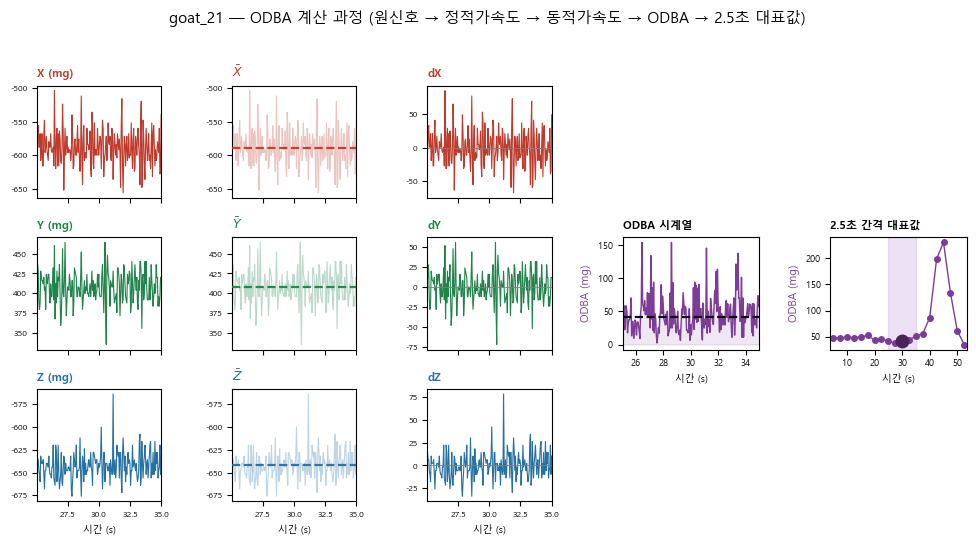

  goat_21: 60s 구간(시작 1745768849700) | 스텝 20개 | 대표창 median=41.6mg -> C:\Users\chs02\OneDrive\바탕 화면\dataset\dataset\processed\전처리\figures에 저장


In [15]:
# =========================================================
# [그림2] - ODBA 계산 과정 (goat 21)
# =========================================================
def plot_odba_process_combined(gid, win_total_sec=60, seed=None, save_dir=FIG_DIR):
    """[raw 3x1 | static 3x1 | dynamic 3x1 | ODBA 1x1 + 대표값 1x1] 레이아웃"""
    acc_cols, fs_hz, median_window_sec = CFG["acc_cols"], CFG["fs_hz"], CFG["median_window_sec"]

    fpath = next(f for f in files_list if get_goat_id(f) == gid)
    df = read_raw_csv(fpath, gid).sort("Time")
    df, _, _ = drop_raw_outliers(df)

    t_ms = df["Time"].to_numpy()
    X = df[acc_cols[0]].to_numpy().astype(float)
    Y = df[acc_cols[1]].to_numpy().astype(float)
    Z = df[acc_cols[2]].to_numpy().astype(float)
    dt = np.diff(t_ms, prepend=t_ms[0])

    win_samples = int(win_total_sec * fs_hz)
    valid_starts = []
    for start in range(0, len(t_ms) - win_samples, 50):
        seg_dt = dt[start + 1:start + win_samples]
        if seg_dt.max() > 55:
            continue
        sx, sy, sz = X[start:start + win_samples], Y[start:start + win_samples], Z[start:start + win_samples]
        if (sx.max() - sx.min() > 4000) or (sy.max() - sy.min() > 4000) or (sz.max() - sz.min() > 4000):
            continue
        valid_starts.append(start)
    if not valid_starts:
        print(f"  goat_{gid:02d}: 조건을 만족하는 연속 구간을 찾지 못함")
        return

    rng = np.random.default_rng(seed)
    start = int(rng.choice(valid_starts))
    sub = df.slice(start, win_samples)

    step_df = compute_odba_step(sub)   # 실제 파이프라인 함수 그대로 사용
    t0 = int(sub["Time"][0])
    step_rel = (step_df["Time"].to_numpy() - t0) / 1000.0
    step_med = step_df["ODBA_step"].to_numpy()
    step_center = step_rel - median_window_sec / 2
    mid = len(step_rel) // 2

    t_sub = (sub["Time"].to_numpy() - t0) / 1000.0
    X_sub = sub[acc_cols[0]].to_numpy().astype(float)
    Y_sub = sub[acc_cols[1]].to_numpy().astype(float)
    Z_sub = sub[acc_cols[2]].to_numpy().astype(float)
    win_end_ms = int(round(step_rel[mid] * 1000)) + t0
    lo0 = np.searchsorted(sub["Time"].to_numpy(), win_end_ms - int(median_window_sec * 1000), side="right")
    hi0 = np.searchsorted(sub["Time"].to_numpy(), win_end_ms, side="right")

    t10 = t_sub[lo0:hi0]
    X10, Y10, Z10 = X_sub[lo0:hi0], Y_sub[lo0:hi0], Z_sub[lo0:hi0]
    Xbar, Ybar, Zbar = X10.mean(), Y10.mean(), Z10.mean()
    dX10, dY10, dZ10 = X10 - Xbar, Y10 - Ybar, Z10 - Zbar
    ODBA_t10 = np.abs(dX10) + np.abs(dY10) + np.abs(dZ10)
    med10 = np.median(ODBA_t10)

    COL = {"X": "#c0392b", "Y": "#1e8449", "Z": "#2471a3"}

    # ---- 한 화면: [raw 3x1, static 3x1, dynamic 3x1, ODBA 1x1 + 대표값 1x1] ----
    fig = plt.figure(figsize=(12, 5.4))
    gs = fig.add_gridspec(3, 5, width_ratios=[1, 1, 1, 1.1, 1.1], wspace=0.55, hspace=0.35)

    blocks = [
        ("원신호", {"X": X10, "Y": Y10, "Z": Z10}),
        ("정적가속도", {"X": (X10, Xbar), "Y": (Y10, Ybar), "Z": (Z10, Zbar)}),
        ("동적가속도", {"X": dX10, "Y": dY10, "Z": dZ10}),
    ]
    for col_idx, (block_name, sig_dict) in enumerate(blocks):
        for row_idx, name in enumerate(["X", "Y", "Z"]):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            if block_name == "원신호":
                ax.plot(t10, sig_dict[name], color=COL[name], linewidth=0.8)
                ax.set_title(f"{name} (mg)", fontsize=8, color=COL[name], loc="left", fontweight="bold")
            elif block_name == "정적가속도":
                sig, bar = sig_dict[name]
                ax.plot(t10, sig, color=COL[name], linewidth=0.8, alpha=0.30)
                ax.axhline(bar, color=COL[name], linestyle="--", linewidth=1.6, alpha=0.95, zorder=5)
                ax.set_title(r"$\bar{%s}$" % name, fontsize=9, color=COL[name], loc="left", fontweight="bold")
            else:
                ax.plot(t10, sig_dict[name], color=COL[name], linewidth=0.8)
                ax.axhline(0, color="gray", linewidth=0.6)
                ax.set_title(f"d{name}", fontsize=8, color=COL[name], loc="left", fontweight="bold")
            ax.tick_params(labelsize=6)
            ax.set_xlim(t10.min(), t10.max())
            if row_idx < 2:
                ax.tick_params(labelbottom=False)
            else:
                ax.set_xlabel("시간 (s)", fontsize=7)

    ax_odba = fig.add_subplot(gs[1, 3])
    ax_odba.plot(t10, ODBA_t10, color="#7d3c98", linewidth=1.0)
    ax_odba.fill_between(t10, 0, ODBA_t10, color="#7d3c98", alpha=0.12)
    ax_odba.axhline(med10, color="black", linestyle="--", linewidth=1.6, alpha=0.95, zorder=5)
    ax_odba.set_ylabel("ODBA (mg)", fontsize=8, color="#7d3c98")
    ax_odba.set_xlabel("시간 (s)", fontsize=7)
    ax_odba.set_title("ODBA 시계열", fontsize=8, fontweight="bold", loc="left")
    ax_odba.tick_params(labelsize=6.5)
    ax_odba.set_xlim(t10.min(), t10.max())

    ax_seq = fig.add_subplot(gs[1, 4])
    ax_seq.axvspan(step_center[mid] - median_window_sec / 2, step_center[mid] + median_window_sec / 2,
                   color="#c9a8dd", alpha=0.35, zorder=0)
    ax_seq.plot(step_center, step_med, "o-", color="#7d3c98", linewidth=1.0, markersize=4)
    ax_seq.plot(step_center[mid], step_med[mid], "o", color="#4a235a", markersize=9, zorder=5)
    ax_seq.set_ylabel("ODBA (mg)", fontsize=8, color="#7d3c98")
    ax_seq.set_xlabel("시간 (s)", fontsize=7)
    ax_seq.set_title("2.5초 간격 대표값", fontsize=8, fontweight="bold", loc="left")
    ax_seq.tick_params(labelsize=6.5)
    ax_seq.set_xlim(step_center.min() - 1, step_center.max() + 1)

    fig.suptitle(f"goat_{gid:02d} \u2014 ODBA 계산 과정 (원신호 \u2192 정적가속도 \u2192 동적가속도 \u2192 ODBA \u2192 2.5초 대표값)",
                 fontsize=11, y=1.02)
    fig.savefig(os.path.join(save_dir, f"goat_{gid:02d}_odba_process_combined.png"), dpi=200,
                bbox_inches="tight", pad_inches=0.1)
    plt.show()

    print(f"  goat_{gid:02d}: {win_total_sec}s 구간(시작 {t_ms[start]}) | 스텝 {len(step_rel)}개 | "
          f"대표창 median={med10:.1f}mg -> {save_dir}에 저장")


if files_list:
    plot_odba_process_combined(gid=21, win_total_sec=60, seed=42)
else:
    print("원시 CSV(goat_*_annotated.csv)를 DATA_DIR에서 찾지 못해 이 시각화는 건너뜁니다.")


[그림3] 분만시각 확인된 개체 26/27개 (censored 등으로 제외: [20])


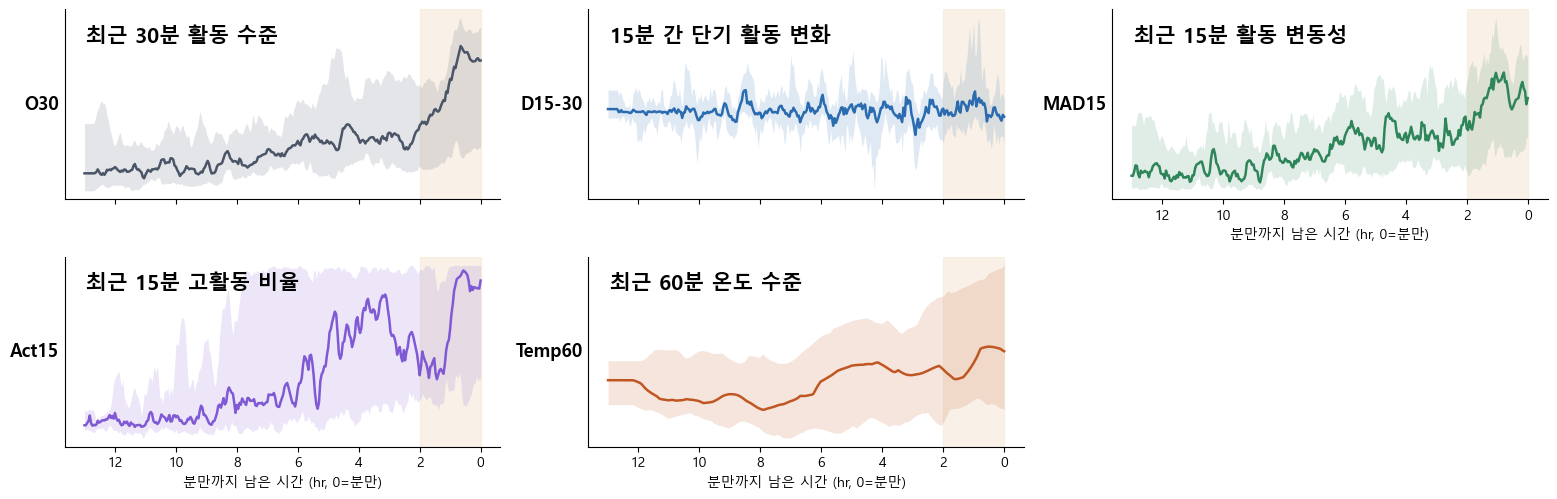

In [16]:
# =========================================================
# [그림3] - 5개 시계열 입력변수 궤적
# =========================================================

def get_birth_time_ms(df, class_col="Class_correct"):
    """class_col==0의 마지막 시각 + 1분 = 분만 시각(추정).
    (Class_correct==-1 라벨이 리샘플링 mode() 집계 과정에서 소실되는 문제를 우회:
     0은 분만 직전 마지막 카운트다운 블록이라 살아남으므로, 그 마지막 시각+1분을 분만 시각으로 역산)
    0이 없으면(censored) None."""
    zero_rows = df.filter(pl.col(class_col) == 0)
    return None if zero_rows.height == 0 else int(zero_rows["Time"].max()) + 60_000


trend_goats = {}   # censored(분만 미관측) 개체는 자동 제외
for gid, df in normalized_final.items():
    bt = get_birth_time_ms(df)
    if bt is None:
        continue
    d = df.select(["Time"] + FINAL_FEATURE_COLS).sort("Time").to_pandas()
    d["time_to_birth_hr"] = (bt - d["Time"]) / 3_600_000
    trend_goats[gid] = d

print(f"[그림3] 분만시각 확인된 개체 {len(trend_goats)}/{len(normalized_final)}개 "
      f"(censored 등으로 제외: {sorted(set(normalized_final) - set(trend_goats))})")


def plot_derived_variable_trend():
    """분만 전 5개 파생변수의 실제 변화 궤적 (전체 개체 중앙값 + IQR, 실제 데이터 기반, 2x3 배열)"""
    grid = np.linspace(13, 0, 300)

    panels = [
        ("O30", "O_30m", "최근 30분 활동 수준", "#4a5568", 0, 0),
        ("D15-30", "D_15-30m", "15분 간 단기 활동 변화", "#2b6cb0", 0, 1),
        ("MAD15", "MAD_15m", "최근 15분 활동 변동성", "#2f855a", 0, 2),
        ("Act15", "Act15m", "최근 15분 고활동 비율", "#805ad5", 1, 0),
        ("Temp60", "Temp_60m", "최근 60분 온도 수준", "#c05621", 1, 1),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16.5, 5.6), sharex=True)

    for name, col, sub_kr, color, r, c in panels:
        ax = axes[r, c]
        traj = []
        for gid, d in trend_goats.items():
            dd = d.dropna(subset=[col])
            ttb = dd["time_to_birth_hr"].to_numpy()
            mask = (ttb >= 0) & (ttb <= 13)
            if mask.sum() < 2:
                continue
            order = np.argsort(ttb[mask])
            ttb_s, y_s = ttb[mask][order], dd[col].to_numpy()[mask][order]
            traj.append(np.interp(grid, ttb_s, y_s))

        if len(traj) == 0:
            ax.text(0.5, 0.5, f"{name}: 유효 데이터 없음", transform=ax.transAxes,
                    ha="center", va="center", fontsize=10, color="gray")
            ax.set_ylabel(name, fontsize=13, rotation=0, ha="right", va="center", fontweight="bold")
            for spine in ["top", "right"]:
                ax.spines[spine].set_visible(False)
            continue

        traj = np.array(traj)
        median_y = np.nanmedian(traj, axis=0)
        q1, q3 = np.nanpercentile(traj, [25, 75], axis=0)

        ax.axvspan(0, CFG["h_target"], color="#f5e9d8", alpha=0.6, zorder=0)
        ax.fill_between(grid, q1, q3, color=color, alpha=0.15, lw=0)
        ax.plot(grid, median_y, color=color, lw=1.8)
        ax.set_yticks([])
        ax.set_ylabel(name, fontsize=13, rotation=0, ha="right", va="center", fontweight="bold")
        ax.text(0.05, 0.80, sub_kr, transform=ax.transAxes, ha="left", va="bottom",
                fontsize=15, color="black", fontweight="bold")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    axes[1, 2].axis("off")
    axes[0, 0].invert_xaxis()
    axes[0, 2].tick_params(axis="x", labelbottom=True)
    axes[1, 0].set_xlabel("분만까지 남은 시간 (hr, 0=분만)", fontsize=10)
    axes[1, 1].set_xlabel("분만까지 남은 시간 (hr, 0=분만)", fontsize=10)
    axes[0, 2].set_xlabel("분만까지 남은 시간 (hr, 0=분만)", fontsize=10)

    fig.tight_layout(rect=[0.05, 0.03, 1, 0.94])
    fig.savefig(os.path.join(FIG_DIR, "derived_variable_trend.png"), dpi=600, bbox_inches="tight")
    plt.show()

plot_derived_variable_trend()